# Homework 5: Modeling Bacterial Growth

### <p style="text-align: right;"> &#9989; Put your name here.


# __CMSE  201 &ndash; Spring 2022__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
## Goals

In this homework, you will use Numpy, SciPy and Matplotlib to model the bacterial growth. This should serve as a good assessment of what you understand at this point in the course. Make sure to use Slack and help room hours if you run into issues!

### By the end of the homework assignment you will have practiced:

1. Using `solve_ivp`
2. Using `matplotlib`
3. Building compartmental models
4. Interpreting model results

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, Apr 1st.** It should be uploaded into the "Homework Assignments" dropbox folder for Homework #5.  Submission instructions can be found at the end of the notebook.

## Grading

* Part 0: Academic integrity statement (1 point)
* Part 1: Preliminary (1 point)
   - Question 1 (1 point)

* Part 2: Find a numerical solution of the Monod type model (35 points)
   - Question 2 (10 points)
   - Question 3 (5 points)
   - Question 4 (10 points)
   - Question 5 (10 points)

* Part 3: First attempt to model the impact of AgNPs (13 points)
   - Question 6 (5 points)
   - Question 7 (8 points)


Total points possible: **50**
___

## Part 0: Academic integrity statement (1 point)

In the markdown cell below, paste your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

## Context

Antimicrobial resistance is among the 10 top threats that human are facing, according to the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/antimicrobial-resistance). As a young scientist, you wish to investigate the bacterial resistance to antimicrobials using _Vibrio cholerae_ as a model microorganism. This pathogen predominantly lives in aquatic environments and is the causative agent of cholera, a virulent disease that still affects millions of people, according to the World Health Organization. You therefore make some experiments to weaken the bacteria using silver nanoparticles (AgNPs) and hopefully come up with a new antimicrobial strategy. You conclude that this approach is promising to fight bacteria.

In order to deepen your knowledge in this field, you now want to initiate yourself to the modeling of bacterial growth based on ordinary differential equations (ODEs). As a first step, you will focus on the modeling of bacterial growth in a liquid environment, where aquatic bacteria such as _Vibrio cholerae_ can be found. More precisely, you are interested in a Monod kinetics growth model given by 

\begin{equation*}
    \begin{aligned}
        \frac{d C_M}{dt} =&\,\, \frac{\mu_1\,C_N}{K_s+C_N}\,C_M \\
        \frac{d C_N}{dt} =&\,\, -\frac{\mu_2\,C_N}{K_s+C_N}\,C_M
    \end{aligned}
\end{equation*}

where $C_M$ is the concentration of bacteria per unit of volume, $C_N$ is the concentration of nutrients per unit per volume, $\mu_1$ is the maximum specific growth rate, $\mu_2>0$ considers the effect of the yield rate and $K_s$ is the concentration of nutrients where the specific growth rate, given by $\frac{\mu_1\,C_N}{K_s+C_N}$ has half its maximum value. 

Your goal is now to understand this model and modify it to consider a more complex situation!

## Part 1: Preliminary (1 point)

**Question 1**: Make sure you set up your notebook to import the right modules that you will need in this homework. 

In [1]:
# Put your code here

# ANSWER
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp

## Part 2: Find a numerical solution of the Monod type model (35 points)

As a first step, you want to find an approximation of the solution of the presented Monod type model for a given initial condition, that is the initial concentration of bacteria and nutrients. 

**Question 2**: Compute the approximation of $C_M$ and $C_N$ for a time interval of $[0,100]$ using `solve_ivp`. You consider that the initial concentration of bacteria and nutrients are respectively $0.03$ and $0.3$, and the following parameters: $K_s = 0.3$, $\mu_1 = 0.05$ and $\mu_2 = 0.3$. 

In [2]:
# Put your code here

# ANSWER

def deriv_func(t,curr_val,mu1,Ks,mu2):
    cm, cn = curr_val
    dcmdt = mu1*cn*cm/(Ks+cn)
    dcndt = -mu2*cn*cm/(Ks+cn)
    return dcmdt, dcndt

y0 = [0.03, 0.3]
mu1 = 0.05
mu2 = 0.3
Ks = 0.3
time_grid = np.arange(0,100+0.1,0.1)

solution = solve_ivp(deriv_func, (time_grid[0],time_grid[-1]),y0,t_eval = time_grid, args=(mu1, Ks, mu2))
cM = solution.y[0,:]
cN = solution.y[1,:]

**Question 3**: Plot the approximations in one figure. Describe the trends you observe. Do the results make sense? 

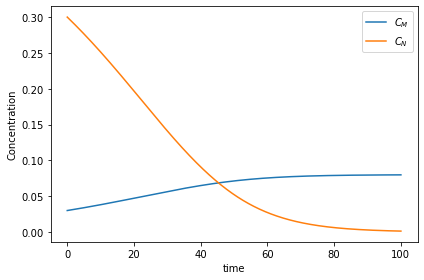

In [3]:
# Put your code here

# ANSWER

plt.plot(time_grid,cM,label='$C_M$')
plt.plot(time_grid,cN,label='$C_N$')
plt.xlabel('time')
plt.ylabel('Concentration')
plt.legend()
plt.tight_layout()

<font size=6 color="#009600">&#9998;</font> *Put your comment here*

**ANSWER**

As expected, the concentration of bacteria increases as the concentration of nutrients decreases.

**Question 4**: Create a function `computeApproxMonodModel` that computes an approximation of $C_M$ and $C_N$ using the function `solve_ivp` of SciPy. The **inputs** are:

1. an array containing the parameters of the model
2. an array containing the initial conditions
3. the time grid

The **outputs** are: 

1. an array that contains the approximation of $C_M$ 
2. an array that contains the approximation of $C_N$

In [4]:
# Put your code here

# ANSWER

def computeApproxMonodModel(param,y0,time_grid):
    mu1 = param[0]
    Ks = param[1]
    mu2 = param[2]
    solution = solve_ivp(deriv_func, (time_grid[0],time_grid[-1]),y0,t_eval = time_grid, args=(mu1, Ks, mu2))
    cM = solution.y[0,:]
    cN = solution.y[1,:]
    return cM, cN 

**Question 5**: Using your function `computeApproxMonodModel`, assess the impact of each parameter on the approximation of $C_M$ and $C_N$. To do so, you want to answer these questions:

1. What will happen if $K_s$ increases/decreases but $\mu_1$ and $\mu_2$ are fixed? 
2. What will happen if $\mu_1$ increases/decreases  but $K_s$ and $\mu_2$ are fixed?
3. What will happen if $\mu_2$ increases/decreases  but $K_s$ and $\mu_1$ are fixed?
4. Do your answers make sense?

To answer these questions, you should vary each parameter, that is $K_s$, $\mu_1$ and $\mu_2$, one at a time. In other words, you should choose three reasonable values for each parameter and observe the impact of this change on the approximation of $C_M$ and $C_N$. Provide numerical evidences of your claims.

**Hint**: Figures with multiple subplots could be useful.

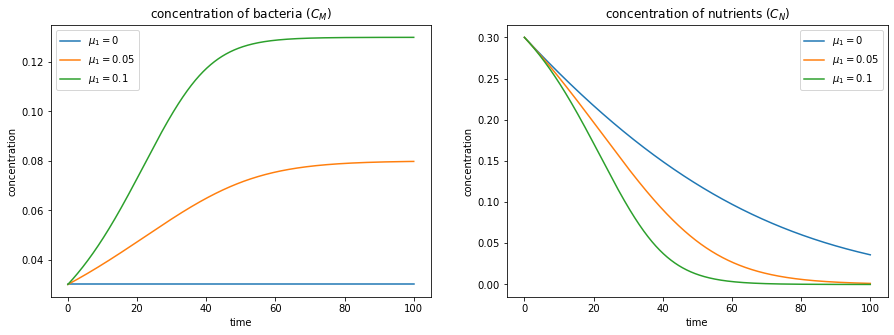

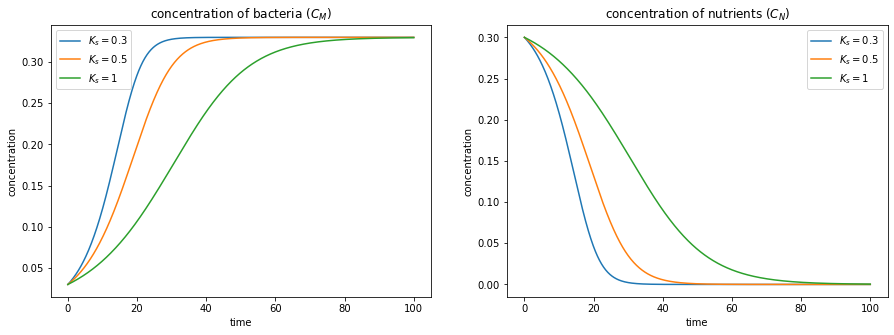

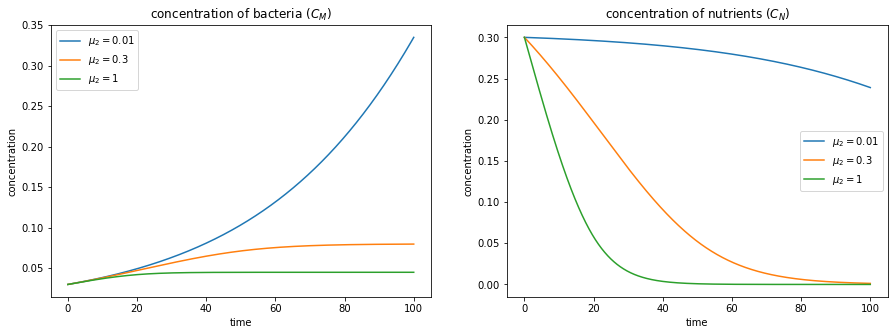

In [5]:
# Put your code here

# ANSWER

y0 = [0.03, 0.3]
time_grid = np.arange(0,100+0.1,0.1)

# mu1 \in {0, 0.05, 0.1}
param = [0, 0.3, 0.3]
cM1, cN1 = computeApproxMonodModel(param,y0,time_grid)
param = [0.05, 0.3, 0.3]
cM2, cN2 = computeApproxMonodModel(param,y0,time_grid)
param = [0.1, 0.3, 0.3]
cM3, cN3 = computeApproxMonodModel(param,y0,time_grid)

figure, axes = plt.subplots(1,2,figsize=[15,5])
axes[0].plot(time_grid, cM1, label='$\mu_1 = 0$')
axes[0].plot(time_grid, cM2, label='$\mu_1 = 0.05$')
axes[0].plot(time_grid, cM3, label='$\mu_1 = 0.1$')
axes[0].set_xlabel('time')
axes[0].set_ylabel('concentration')
axes[0].title.set_text('concentration of bacteria ($C_M$)')
axes[0].legend()
axes[1].plot(time_grid, cN1, label='$\mu_1 = 0$')
axes[1].plot(time_grid, cN2, label='$\mu_1 = 0.05$')
axes[1].plot(time_grid, cN3, label='$\mu_1 = 0.1$')
axes[1].set_xlabel('time')
axes[1].set_ylabel('concentration')
axes[1].title.set_text('concentration of nutrients ($C_N$)')
axes[1].legend()



# Ks \in {0.3, 0.5, 1.0}
param = [0.3, 0.3, 0.3]
cM1, cN1 = computeApproxMonodModel(param,y0,time_grid)
param = [0.3, 0.5, 0.3]
cM2, cN2 = computeApproxMonodModel(param,y0,time_grid)
param = [0.3, 1.0, 0.3]
cM3, cN3 = computeApproxMonodModel(param,y0,time_grid)

figure, axes = plt.subplots(1,2,figsize=[15,5])
axes[0].plot(time_grid, cM1, label='$K_s = 0.3$')
axes[0].plot(time_grid, cM2, label='$K_s = 0.5$')
axes[0].plot(time_grid, cM3, label='$K_s = 1$')
axes[0].set_xlabel('time')
axes[0].set_ylabel('concentration')
axes[0].title.set_text('concentration of bacteria ($C_M$)')
axes[0].legend()
axes[1].plot(time_grid, cN1, label='$K_s = 0.3$')
axes[1].plot(time_grid, cN2, label='$K_s = 0.5$')
axes[1].plot(time_grid, cN3, label='$K_s = 1$')
axes[1].set_xlabel('time')
axes[1].set_ylabel('concentration')
axes[1].title.set_text('concentration of nutrients ($C_N$)')
axes[1].legend()



# mu2 \in {0.01, 0.3, 1.0}
param = [0.05, 0.3, 0.01]
cM1, cN1 = computeApproxMonodModel(param,y0,time_grid)
param = [0.05, 0.3, 0.3]
cM2, cN2 = computeApproxMonodModel(param,y0,time_grid)
param = [0.05, 0.3, 1.0]
cM3, cN3 = computeApproxMonodModel(param,y0,time_grid)

figure, axes = plt.subplots(1,2,figsize=[15,5])
axes[0].plot(time_grid, cM1, label='$\mu_2 = 0.01$')
axes[0].plot(time_grid, cM2, label='$\mu_2 = 0.3$')
axes[0].plot(time_grid, cM3, label='$\mu_2 = 1$')
axes[0].set_xlabel('time')
axes[0].set_ylabel('concentration')
axes[0].title.set_text('concentration of bacteria ($C_M$)')
axes[0].legend()
axes[1].plot(time_grid, cN1, label='$\mu_2 = 0.01$')
axes[1].plot(time_grid, cN2, label='$\mu_2 = 0.3$')
axes[1].plot(time_grid, cN3, label='$\mu_2 = 1$')
axes[1].set_xlabel('time')
axes[1].set_ylabel('concentration')
axes[1].title.set_text('concentration of nutrients ($C_N$)')
axes[1].legend()

<font size=6 color="#009600">&#9998;</font> *Put your comment here* 
### Answer
Give the points if it makes sense

## Part 3: First attempt to model the impact of AgNPs (13 points)

Now that you better understand the model to predict the bacterial growth, you want to consider the impact of the concentration of silver nanoparticles (AgNPs) - an antimicrobial agent, on the bacterial concentration. As a first attempt, you assume the decay rate, $k_A$, associated with the concentration of AgNPs is **known**. In this part, you will consider that the initial concentration of bacteria and nutrients at $t=0$ are respectively $0.03$ and $0.3$, and the following parameters: $K_s = 0.3$, $\mu_1 = 0.05$ and $\mu_2 = 0.3$.

**Question 6**: Modify the presented Monod model in order to consider the impact of AgNPs.

**Hint**: You should use a compartmental representation of the basic Monod model to help you and modify it considering that the AgNP is killing off/decreasing the concentration of bacteria ($C_M$). In this context, $k_A$ is the rate at which the bacteria concentration is decreasing.

**Hint**: You could use Latex to write equations in a Markdown cell. The Monod type model below is provided to give you a nice example of how you could write your model.

\begin{equation*}
    \begin{aligned}
        \frac{d C_M}{dt} =&\,\, \frac{\mu_1\,C_N}{K_s+C_N}\,C_M \\
        \frac{d C_N}{dt} =&\,\, -\frac{\mu_2\,C_N}{K_s+C_N}\,C_M
    \end{aligned}
\end{equation*}

It is **not required** that you use this format but it is strongly suggested.  

<font size=6 color="#009600">&#9998;</font> *Put your model here*

**ANSWER**

If the student uses a compartmental representation of the basic Monod model, he could figure out how to add the death of bacteria due to AgNPs. 

One possible answer:

\begin{equation*}
    \begin{aligned}
        \frac{d C_M}{dt} =&\,\, \frac{\mu_1\,C_N}{K_s+C_N}\,C_M - k_A\,C_M \\
        \frac{d C_N}{dt} =&\,\, -\frac{\mu_2\,C_N}{K_s+C_N}\,C_M
    \end{aligned}
\end{equation*}

**Question 7**: Using `solve_ivp`, assess the impact of the decay rate associated to the concentration of AgNPs on the concentration of bacteria. To do so, you want to answer these questions:

1. What will happen if $k_A$ is 0?
2. What will happen if $k_A$ increases/decreases but $K_s$, $\mu_1$ and $\mu_2$ are fixed? 
3. Do your answers make sense?

In other words, you should choose three reasonable values for $k_A$ that you added in the model and observe the impact of this change on the approximation of $C_M$ and $C_N$. Provide numerical evidences of your claims.

In [6]:
# Put your code here

# Answer

def deriv_func1(t,curr_val,mu1,Ks,mu2,k):
    cm, cn = curr_val
    dcmdt = mu1*cn*cm/(Ks+cn)-k*cm
    dcndt = -mu2*cn*cm/(Ks+cn)
    return dcmdt, dcndt

In [7]:
# ANSWER

## NOTE: HERE THEY DO NOT NEED TO USE A FUNCTION LIKE computeApproxMonodModel1 TO OBTAIN THE FULL GRADE

def computeApproxMonodModel1(param,y0,time_grid):
    mu1 = param[0]
    Ks = param[1]
    mu2 = param[2]
    k = param[3]
    solution = solve_ivp(deriv_func1, (time_grid[0],time_grid[-1]),y0,t_eval = time_grid, args=(mu1, Ks, mu2, k))
    cM = solution.y[0,:]
    cN = solution.y[1,:]
    return cM, cN 

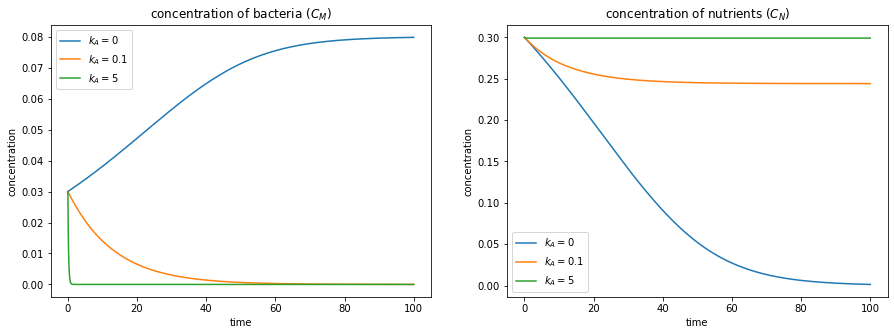

In [8]:
# ANSWER

# k \in {0, 0.1, 5}
param = [0.05, 0.3, 0.3, 0]
cM1, cN1 = computeApproxMonodModel1(param,y0,time_grid)
param = [0.05, 0.3, 0.3, 0.1]
cM2, cN2 = computeApproxMonodModel1(param,y0,time_grid)
param = [0.05, 0.3, 0.3, 5]
cM3, cN3 = computeApproxMonodModel1(param,y0,time_grid)

figure, axes = plt.subplots(1,2,figsize=[15,5])
axes[0].plot(time_grid, cM1, label='$k_A = 0$')
axes[0].plot(time_grid, cM2, label='$k_A = 0.1$')
axes[0].plot(time_grid, cM3, label='$k_A = 5$')
axes[0].set_xlabel('time')
axes[0].set_ylabel('concentration')
axes[0].title.set_text('concentration of bacteria ($C_M$)')
axes[0].legend()
axes[1].plot(time_grid, cN1, label='$k_A = 0$')
axes[1].plot(time_grid, cN2, label='$k_A = 0.1$')
axes[1].plot(time_grid, cN3, label='$k_A = 5$')
axes[1].set_xlabel('time')
axes[1].set_ylabel('concentration')
axes[1].title.set_text('concentration of nutrients ($C_N$)')
axes[1].legend()

<font size=6 color="#009600">&#9998;</font> *Put your comment here* 

**ANSWER**

Give the points if it makes sense

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework #5, and upload it there.